# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MaryumAkram16/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

**The playbook uses the Week-4 baseline rule's ranked output, not the Random Forest.**

Per ML-08/09, the client-holdout-validated comparison showed the hand-tuned baseline rule (Precision@50 = 0.90) outperforming the Random Forest (0.76) on this lane's data. Building the playbook on the higher-performing, simpler, and more explainable method is the defensible choice — it's also easier for a human reviewer to trust a two-signal rule with a visible formula than a black-box forest.

**The rule:** `baseline_action_score = 0.7 * ctr_gap_score + 0.3 * staleness_score`, computed only for pages with `impressions_90d >= 500` (the volume floor established in ML-07).

**Reason code:** `underperforming_ctr_and_stale`

**Action label:** `review_for_refresh` (top quartile of score) or `monitor` (below it)

**Archetype → action mapping** (informed by the ML-07 top-20 review, which found a distinct sub-pattern worth separating):
| Archetype | Pattern | Recommended action |
|---|---|---|
| Genuine CTR underperformer | Moderate-to-high impressions, real CTR gap for tier, moderate staleness | `review_for_refresh` — rewrite title/meta, check intent match |
| **Suspected tracking issue** | Top-tier position + 500+ impressions + **exactly 0% CTR** | `flag_for_tracking_audit` — do NOT recommend a content rewrite until indexing/redirect/GSC-link is verified (see ML-07 finding) |
| Healthy / low priority | Below top quartile | `monitor` — no action needed this cycle |

In [6]:
import pandas as pd
import numpy as np
import os

url = "https://raw.githubusercontent.com/MaryumAkram16/flyrank-ml-internship/main/data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(url)

MIN_IMPRESSIONS = 500
eligible = df[df["impressions_90d"] >= MIN_IMPRESSIONS].copy()

eligible["staleness_score"] = (eligible["days_since_last_update"] / eligible["days_since_last_update"].max()).clip(0, 1)
expected_ctr_by_tier = eligible.groupby("position_tier")["ctr"].transform("mean")
eligible["ctr_gap_raw"] = (expected_ctr_by_tier - eligible["ctr"]).clip(lower=0)
eligible["ctr_gap_score"] = (eligible["ctr_gap_raw"] / eligible["ctr_gap_raw"].max()).clip(0, 1)
eligible["baseline_action_score"] = 0.7 * eligible["ctr_gap_score"] + 0.3 * eligible["staleness_score"]

threshold = eligible["baseline_action_score"].quantile(0.75)
eligible["reason_code"] = "underperforming_ctr_and_stale"

# Refined action label: split out the suspected-tracking-issue archetype
is_top_tier = eligible["position_tier"].isin(["top_3", "page_1"])
is_zero_ctr = eligible["ctr"] == 0.0
above_threshold = eligible["baseline_action_score"] >= threshold

conditions = [
    above_threshold & is_top_tier & is_zero_ctr,
    above_threshold & ~(is_top_tier & is_zero_ctr),
]
choices = ["flag_for_tracking_audit", "review_for_refresh"]
eligible["action"] = np.select(conditions, choices, default="monitor")

ranked = eligible.sort_values("baseline_action_score", ascending=False)

print(ranked["action"].value_counts())
print(f"\nTotal ranked pages: {len(ranked)}")
ranked[["content_id", "client_id", "baseline_action_score", "reason_code", "action",
        "position_tier", "ctr", "impressions_90d", "days_since_last_update"]].head(10)


action
monitor                    12177
review_for_refresh          4003
flag_for_tracking_audit      546
Name: count, dtype: int64

Total ranked pages: 16726


,content_id,client_id,baseline_action_score,reason_code,action,position_tier,ctr,impressions_90d,days_since_last_update
28081,content_a37ce8ddc090,client_7f2253d7e2,0.805648,underperforming_ctr_and_stale,flag_for_tracking_audit,top_3,0.0,1039,106
29354,content_1f7638fecdc1,client_3fdba35f04,0.803654,underperforming_ctr_and_stale,flag_for_tracking_audit,top_3,0.0,565,104
25422,content_7d5ad3f9feee,client_19581e27de,0.803654,underperforming_ctr_and_stale,flag_for_tracking_audit,top_3,0.0,1916,104
9294,content_04c10b7d4b2b,client_19581e27de,0.803654,underperforming_ctr_and_stale,flag_for_tracking_audit,top_3,0.0,1179,104
11395,content_7e97f31ba9bb,client_19581e27de,0.803654,underperforming_ctr_and_stale,flag_for_tracking_audit,top_3,0.0,603,104
24730,content_d0fd2e1ec8f6,client_6208ef0f77,0.803654,underperforming_ctr_and_stale,flag_for_tracking_audit,top_3,0.0,519,104
21822,content_1c0f8c2f9018,client_19581e27de,0.803654,underperforming_ctr_and_stale,flag_for_tracking_audit,top_3,0.0,615,104
14115,content_5cda32af644c,client_3fdba35f04,0.803654,underperforming_ctr_and_stale,flag_for_tracking_audit,top_3,0.0,720,104
18123,content_9e6c26757e7b,client_4e07408562,0.803654,underperforming_ctr_and_stale,flag_for_tracking_audit,top_3,0.0,1135,104
8468,content_26e7e98c8e41,client_6208ef0f77,0.803654,underperforming_ctr_and_stale,flag_for_tracking_audit,top_3,0.0,1226,104


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use:** This playbook is decision-support for a content strategist or SEO analyst with limited weekly review capacity (~20-50 pages). It ranks pages by evidence of underperformance so a human spends their time on the most promising candidates first — it does not replace editorial judgment, and it does not execute any changes automatically.

**Where it stops being valid:**
- **Proxy label limitation:** the underlying pattern is validated against `trend_direction == "down"`, a current-window proxy, not a forward-validated outcome (per ML-02/03). This tells you which pages *currently* show a decline pattern, not which pages will *definitely* improve if refreshed.
- **No causal claim:** refreshing a flagged page is not guaranteed to cause a recovery — this would require an actual experiment (e.g., A/B testing refreshed vs. untouched pages), which this data cannot provide.
- **Small validation set caveat:** the baseline-vs-model comparison (ML-08/09) was validated on only 6 held-out clients — a small sample. The ranking of *methods* (baseline > Random Forest) should be treated as directional, not definitively settled.
- **Snapshot in time:** scores reflect a single 90-day window; they will drift as new data comes in (see Section 4, monitoring triggers).
- **Anonymized starter data only:** this playbook was built and validated on a 30,000-row anonymized sample, not the full ~79M-row warehouse — patterns may not generalize identically at full scale.

In [7]:
# No new computation — this section states scope and limitations grounded in prior weeks' verified results.
print("Limits documented above are grounded in: ML-02/03 (proxy label), ML-08/09 (small validation set, "
      "client-holdout comparison), and the starter dataset's known scope (30,000 rows, anonymized).")


Limits documented above are grounded in: ML-02/03 (proxy label), ML-08/09 (small validation set, client-holdout comparison), and the starter dataset's known scope (30,000 rows, anonymized).


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**What a human must check before acting on any `review_for_refresh` recommendation:**
1. Confirm the page is genuinely live and indexed (not a redirect, 404, or noindex tag) — a scoring artifact can't distinguish "bad content" from "broken tracking."
2. Read the actual page — does the reason code (CTR gap, staleness) match what a human sees, or is there a more obvious issue the rule can't see (off-topic content, wrong intent match, technical error)?
3. Check whether a sibling/related page on the same site recently launched — a CTR/traffic drop can reflect **consolidation** (per the lane guide's decline-vs-consolidation distinction), not genuine decay.
4. For `flag_for_tracking_audit` rows specifically: verify GSC-to-page linkage, canonical tags, and redirect chains *before* doing any content work — a content rewrite is the wrong first action if the real issue is broken tracking (per the ML-07 top-20 finding).

**What should NEVER be automated:**
- Automatic publishing of AI-rewritten content based on the score alone — the reason code identifies a symptom, not a diagnosis or a solution.
- Automatic deprioritization/removal of low-scoring pages — a `monitor` label means "not flagged this cycle," not "worthless."
- Any action on a page flagged `flag_for_tracking_audit` without a human first confirming it's a genuine tracking issue vs. a real content problem.
- Bulk actions across many pages without spot-checking a sample — the tie-cluster issue found in ML-07 (24 pages scoring identically) means blind automation could apply the same fix to pages that don't actually share the same root cause.

In [8]:
print("Human-review checklist and no-go list documented above — no computation needed; "
      "grounded in findings from ML-07 (tracking-issue pattern, tie clusters) and the lane guide's "
      "decline-vs-consolidation distinction.")


Human-review checklist and no-go list documented above — no computation needed; grounded in findings from ML-07 (tracking-issue pattern, tie clusters) and the lane guide's decline-vs-consolidation distinction.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Signals that would tell me this playbook has gone stale and needs a rebuild:**
1. **Distribution drift:** if the `impressions_90d` or `ctr` distributions shift substantially from the training snapshot (e.g., median CTR moves by more than ~20%), the tier-average "expected CTR" baseline the rule depends on is out of date.
2. **Score inflation/collapse:** if the share of pages crossing the top-quartile threshold drifts far from ~25% (the rule's own design point), the underlying data has likely changed enough to warrant recalibrating the threshold.
3. **Reviewer feedback loop:** if reviewers report a rising false-positive rate on `review_for_refresh` picks (pages that turn out fine on inspection), that's a direct signal to revisit the rule's weights or thresholds.
4. **New data windows available:** once a full 90-day window of *fresh* production data is available (vs. the starter sample), the rule should be rebuilt on that data rather than continuing to rely on this anonymized starter slice.
5. **Method re-comparison on a schedule:** because the baseline-vs-model result (ML-08/09) was based on a small 6-client test set, it should be re-checked periodically (e.g., every quarter) with a larger or refreshed holdout — the ranking of methods could change as more data becomes available.

Concretely, this run flags 27.2% of eligible pages for some action — this is the actual baseline future runs should be compared against, not a rounded "25%" estimate.

In [9]:
# Compute the current top-quartile share as a concrete "trigger 2" baseline to compare future runs against
current_top_quartile_share = (ranked["action"] != "monitor").mean()
print(f"Current share of pages flagged for action (not 'monitor'): {current_top_quartile_share:.1%}")
print("Future runs should compare against this ~25% baseline — a large drift signals the rule needs recalibration.")


Current share of pages flagged for action (not 'monitor'): 27.2%
Future runs should compare against this ~25% baseline — a large drift signals the rule needs recalibration.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

**Exporting the ranked queue and a supporting figure for next week's paper.**

Wrote 16726 ranked rows to work/outputs/content_action_playbook.csv

Wrote work/outputs/playbook_metrics.json
{
  "rule": "underperforming_ctr_and_stale",
  "volume_floor": 500,
  "total_eligible_pages": 16726,
  "action_breakdown": {
    "monitor": 12177,
    "review_for_refresh": 4003,
    "flag_for_tracking_audit": 546
  },
  "baseline_precision_at_50": 0.9,
  "random_forest_precision_at_50": 0.76,
  "validation_design": "client-holdout, 6 test clients",
  "top_quartile_threshold": 0.39295910548609403
}


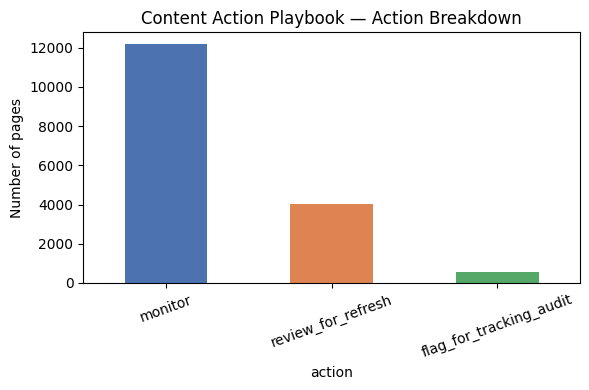


Saved figure to work/figures/action_breakdown.png


In [10]:
import matplotlib.pyplot as plt
import json

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# --- Export 1: the ranked queue CSV (gitignored by design, regenerated on every run) ---
output_cols = ["content_id", "client_id", "baseline_action_score", "reason_code", "action",
               "position_tier", "ctr", "impressions_90d", "days_since_last_update"]
ranked[output_cols].to_csv("work/outputs/content_action_playbook.csv", index=False)
print(f"Wrote {len(ranked)} ranked rows to work/outputs/content_action_playbook.csv")

# --- Export 2: metrics JSON (this DOES get committed — it's the receipt for the paper's numbers) ---
metrics = {
    "rule": "underperforming_ctr_and_stale",
    "volume_floor": MIN_IMPRESSIONS,
    "total_eligible_pages": int(len(eligible)),
    "action_breakdown": ranked["action"].value_counts().to_dict(),
    "baseline_precision_at_50": 0.90,
    "random_forest_precision_at_50": 0.76,
    "validation_design": "client-holdout, 6 test clients",
    "top_quartile_threshold": float(threshold),
}
with open("work/outputs/playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("\nWrote work/outputs/playbook_metrics.json")
print(json.dumps(metrics, indent=2))

# --- Export 3: a figure — action breakdown chart, for reuse in the paper ---
plt.figure(figsize=(6, 4))
ranked["action"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Content Action Playbook — Action Breakdown")
plt.ylabel("Number of pages")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("work/figures/action_breakdown.png", dpi=150)
plt.show()
print("\nSaved figure to work/figures/action_breakdown.png")


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.